# Sprint 1 · EDA orientado a decisión — detección de eventos adversos en epicrisis MIMIC-IV

**Curso:** MIA-14 Trabajo de Investigación II · **Autor:** Carlos Pérez Pérez · **Entrada:** `data/processed/dataset.parquet` (salida de `src/preprocesado.py`).

Este EDA no describe por describir: cada sección prueba una **hipótesis de riesgo** que, si se confirma, invalidaría o sesgaría el modelo.

| # | Pregunta | Riesgo que vigila |
|---|---|---|
| 1 | ¿Cuánto hay y cómo está balanceado? | desbalance; métrica engañosa |
| 2 | ¿La época de codificación (CIE-9 / CIE-10) separa las clases? | confusor ya detectado en la tesis (drift de codificación) |
| 3 | ¿El largo de la nota separa las clases por sí solo? | atajo (*shortcut*) |
| 4 | ¿Aparecen códigos CIE escritos dentro del texto? | fuga directa de la etiqueta (*label leakage*) |
| 5 | ¿Hay pacientes en train y test a la vez? | fuga por paciente |
| 6 | ¿Cómo se reparten las naturalezas del evento? | clases raras para la etapa 2 |

**Regla de datos:** MIMIC-IV está bajo DUA de PhysioNet. Este notebook muestra **solo agregados**; no imprime texto clínico.

In [1]:
import json, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_parquet(RAIZ / "data/processed/dataset.parquet")
resumen = json.loads((RAIZ / "reportes/preprocesado_resumen.json").read_text(encoding="utf-8"))
print(f"{len(df):,} notas · {df.subject_id.nunique():,} pacientes · {df.hadm_id.nunique():,} hospitalizaciones")
print("prevalencia real en MIMIC-IV:", resumen["prevalencia_real"])

70,000 notas · 48,669 pacientes · 70,000 hospitalizaciones
prevalencia real en MIMIC-IV: 0.2012


## 1. Volumen y balance de clases

In [2]:
t = pd.crosstab(df.split, df.y, margins=True)
t.columns = ["negativa", "positiva", "total"]
t["% positivas"] = (100 * t.positiva / t.total).round(1)
t

,negativa,positiva,total,% positivas
split,,,,
test,6528,7557,14085,53.7
train,25780,30135,55915,53.9
All,32308,37692,70000,53.8


## 2. Época de codificación por clase (confusor)
Si las positivas fueran mayoritariamente de una época, el modelo aprendería la época y no el evento. La tesis ya lo encontró (AUC inflado a 0.973) y lo corrigió emparejando. Aquí se verifica que el emparejamiento se sostiene y se mide el **AUC de la época sola** como predictor: debe ser ≈ 0.5.

In [3]:
ep = pd.crosstab(df.y, df.epoca, normalize="index").mul(100).round(1)
ep.index = ["negativa", "positiva"]; ep.columns = [f"CIE-{int(c)} %" for c in ep.columns]
display(ep)
print(f"AUC de la época sola: {roc_auc_score(df.y, df.epoca):.3f}")

,CIE-9 %,CIE-10 %
negativa,71.1,28.9
positiva,71.1,28.9


AUC de la época sola: 0.500


## 3. Largo de la nota por clase (atajo)

            count     mean     std    min     25%      50%      75%      max
y                                                                           
negativa  32308.0   9703.0  3807.0  353.0  7033.0   9185.0  11804.0  49439.0
positiva  37692.0  11525.0  5106.0  697.0  7945.0  10717.0  14094.0  58156.0

AUC del largo solo: 0.606


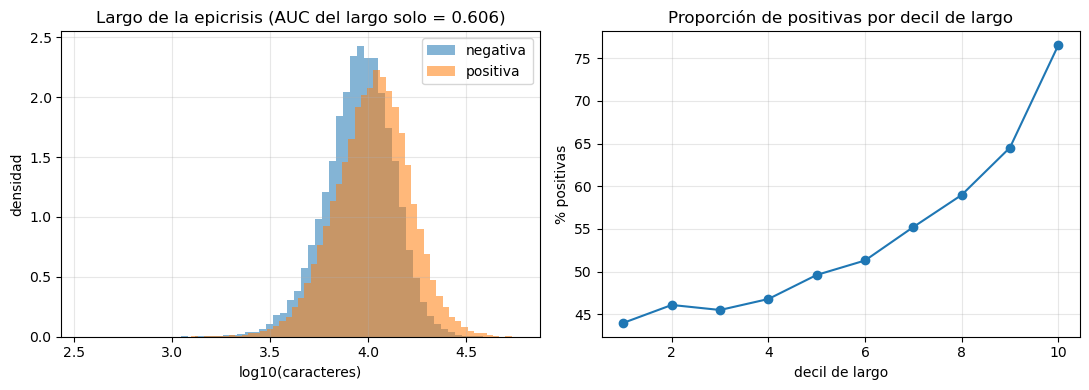

In [4]:
df["largo"] = df.text.str.len()
print(df.groupby("y").largo.describe(percentiles=[.25,.5,.75]).round(0).rename(index={0:"negativa",1:"positiva"}))
auc_largo = roc_auc_score(df.y, df.largo)
print(f"\nAUC del largo solo: {auc_largo:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for y, nombre in [(0, "negativa"), (1, "positiva")]:
    ax[0].hist(np.log10(df.loc[df.y == y, "largo"]), bins=60, alpha=.55, density=True, label=nombre)
ax[0].set(xlabel="log10(caracteres)", ylabel="densidad", title=f"Largo de la epicrisis (AUC del largo solo = {auc_largo:.3f})")
ax[0].legend()
dec = pd.qcut(df.largo, 10, labels=False)
ax[1].plot(range(1, 11), df.groupby(dec).y.mean().values * 100, "o-")
ax[1].set(xlabel="decil de largo", ylabel="% positivas", title="Proporción de positivas por decil de largo")
for a in ax: a.grid(alpha=.3)
fig.tight_layout()
fig.savefig(RAIZ / "reportes/figuras/fig_eda_largo.png", dpi=160)

## 4. ¿Hay códigos CIE escritos en el texto? (fuga directa)
La etiqueta sale de los códigos CIE de facturación. Si la nota los trajera escritos, el modelo leería la respuesta.

In [5]:
pat_cie10 = re.compile(r"\b[A-TV-Z]\d{2}\.\d{1,4}\b")
pat_cie9 = re.compile(r"\b(?:E|V)?\d{3}\.\d{1,2}\b")
df["tiene_cie10"] = df.text.str.contains(pat_cie10)
df["tiene_cie9_like"] = df.text.str.contains(pat_cie9)
df.groupby("y")[["tiene_cie10", "tiene_cie9_like"]].mean().mul(100).round(2).rename(index={0:"negativa",1:"positiva"})

,tiene_cie10,tiene_cie9_like
y,,
negativa,4.45,27.97
positiva,4.95,33.40


*Nota:* el patrón tipo CIE-9 (`123.45`) también captura números decimales comunes (dosis, laboratorio); por eso la comparación relevante es la **diferencia entre clases**, no el nivel.

## 5. Pacientes y fuga por paciente

In [6]:
npp = df.groupby("subject_id").size()
print("notas por paciente:", npp.describe().round(2).to_dict())
comp = set(df[df.split=="train"].subject_id) & set(df[df.split=="test"].subject_id)
print("pacientes compartidos train/test:", len(comp))

notas por paciente: {'count': 48669.0, 'mean': 1.44, 'std': 1.12, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 1.0, 'max': 27.0}
pacientes compartidos train/test: 0


## 6. Naturaleza del evento entre las positivas (etapa 2)

In [7]:
nat = df[df.y == 1].labels.explode().value_counts()
multi = (df[df.y == 1].labels.str.len() > 1).mean()
print(f"positivas con más de una naturaleza: {100*multi:.1f} %")
(nat.to_frame("notas").assign(pct=lambda d: (100*d.notas/ (df.y==1).sum()).round(2)))

positivas con más de una naturaleza: 5.0 %


,notas,pct
labels,,
Procedimiento,17209,45.66
Cuidado del paciente,10305,27.34
Medicacion,9933,26.35
Dispositivo medico,1198,3.18
Infeccion nosocomial,1007,2.67
Sistema/Organizacion,130,0.34


## Conclusiones accionables

Cada cifra sale de las celdas de arriba o de `reportes/baseline_resultados.json`.

| # | Hallazgo | Decisión para el Sprint 2 |
|---|---|---|
| 1 | El corpus tiene **53.8 % de positivas**, pero la prevalencia real en MIMIC-IV es **20.12 %**. La precisión y el F1 del test están inflados por construcción. | La métrica principal es el **AUC**, y como métrica operativa se reporta el **VPP corregido a la prevalencia real** (Bayes). El F1 del test no se usa como cifra principal. |
| 2 | La época está emparejada: **71.1 % CIE-9 / 28.9 % CIE-10 en ambas clases; el AUC de la época sola es 0.500**. | El confusor de época está controlado. Se conserva el emparejamiento y se agrega esta prueba al pipeline como aserción. |
| 3 | Las positivas son más largas (mediana de **10 717** frente a **9 185** caracteres) y el **largo solo da un AUC de 0.606**. | Hay un **riesgo moderado de atajo**. En el Sprint 2 se reporta el AUC dentro de los deciles de largo y se prueba una feature de control, para verificar que el modelo no aprende «nota larga = evento». |
| 4 | Aparecen códigos con formato CIE-10 en **4.45 %** de las negativas y **4.95 %** de las positivas: una diferencia de 0.5 puntos. | La fuga directa de la etiqueta es baja. En el Sprint 2 va una ablación que enmascara los patrones de código antes de vectorizar. |
| 5 | **0 pacientes compartidos** entre train y test; hay **1.44 notas por paciente** en promedio (máximo 27). | La validación cruzada del Sprint 2 debe ser **por paciente (GroupKFold)**, nunca K-fold simple. |
| 6 | En la etapa 2, **Sistema/Organización tiene solo 130 notas (0.34 %)**; Dispositivo e Infección no llegan al 3.2 %. | Esa clase no es evaluable con este volumen: se reporta aparte o se fusiona. Para las clases raras, ponderar o usar F1-macro con IC. |
| 7 | En el baseline, **la logística TF-IDF (AUC 0.864; IC 0.858–0.869) supera al LinearSVC de la tesis (AUC 0.843; IC 0.836–0.848)** en la misma partición, y tarda 4 min frente a 33. | La logística pasa a ser el **baseline a batir** en el Sprint 2. La elección del modelo de la tesis tiene que justificarse frente a ella. |

**Limitación que se declara:** la etiqueta es **débil**, porque sale de códigos CIE de facturación y no de una lectura clínica. Mide «nota de una hospitalización con código de evento adverso», no «nota que describe un evento». La validación con el panel experto queda como evidencia secundaria (decisión del autor del 20-09-2026).